# Лабораторная работа E3 — Цифровые фильтры: убрать лишние частоты

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e3.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e3.html)**.

**Что разбираем.** В лабе E2 мы научились смотреть, из каких частот состоит
сигнал. Теперь научимся лишние частоты выбрасывать.

Фильтр — это кривая усиления по частоте: где она близка к 1, частота проходит;
где близка к 0, частота гасится. Для ЭМГ стандартный набор такой:

* **ФВЧ** около 20 Гц — убирает дрейф изолинии и движения электрода;
* **ФНЧ** около 450 Гц (здесь 160 Гц, т.к. частота дискретизации ниже) —
  убирает высокочастотный шум;
* **notch** на 50 Гц — вырезает наводку от сети.

Отдельный вопрос — **фазовая задержка**. Обычный фильтр сдвигает сигнал во
времени. Приём `filtfilt` (прогон вперёд и назад) убирает сдвиг полностью, но
работает только офлайн: для этого нужно знать будущее сигнала.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
from scipy import signal

## Ячейка 2 · Вспомогательные функции

Сборка тестового сигнала, спектр, применение фильтров и рисование.
Запусти один раз и дальше просто вызывай.

In [3]:
def make_signal(components, fs, n, noise=0.16, seed=0):
    """Сумма синусов (частота, амплитуда) плюс шум."""
    rng = np.random.default_rng(seed)
    t = np.arange(n) / fs
    s = noise * rng.standard_normal(n)
    for freq, amp in components:
        s += amp * np.sin(2 * np.pi * freq * t)
    return t, s


def spectrum(x, fs):
    n = len(x)
    return np.fft.rfftfreq(n, d=1.0 / fs), 2 * np.abs(np.fft.rfft(x)) / n


def bandpass(x, band, fs, order=4):
    """Полосовой Баттерворта, прогнанный вперёд-назад: без фазового сдвига."""
    sos = signal.butter(order, band, btype="bandpass", fs=fs, output="sos")
    return signal.sosfiltfilt(sos, x)


def notch(x, freq, fs, q=30.0):
    """Узкий режекторный фильтр — вырезает одну частоту (обычно сетевые 50 Гц)."""
    b, a = signal.iirnotch(freq, Q=q, fs=fs)
    return signal.filtfilt(b, a, x)


def response(band, fs, notch_freq=None, order=4, n_points=2048):
    """АЧХ всей цепочки фильтров: как усиливается каждая частота."""
    sos = signal.butter(order, band, btype="bandpass", fs=fs, output="sos")
    freqs, h = signal.sosfreqz(sos, worN=n_points, fs=fs)
    gain = np.abs(h) ** 2                     # квадрат, т.к. проход вперёд-назад
    if notch_freq:
        b, a = signal.iirnotch(notch_freq, Q=30.0, fs=fs)
        _, h_notch = signal.freqz(b, a, worN=n_points, fs=fs)
        gain = gain * np.abs(h_notch) ** 2
    return freqs, gain


def report_components(components, freqs, before, after, fs, n):
    """Показывает амплитуду каждой заданной компоненты до и после фильтра."""
    print("%8s %10s %10s   %s" % ("частота", "до", "после", "что произошло"))
    for freq, _amp in components:
        k = int(round(freq / (fs / n)))
        drop = after[k] / before[k] if before[k] > 1e-9 else 0.0
        verdict = "прошла" if drop > 0.5 else ("ослаблена" if drop > 0.05 else "убрана")
        print("%6g Гц %10.2f %10.2f   %s (%.0f%%)"
              % (freq, before[k], after[k], verdict, 100 * drop))


def plot_before_after(t, raw, filtered, fs, band, notch_freq):
    """Три панели: АЧХ фильтра, спектр до/после, сигнал до/после."""
    f_raw, s_raw = spectrum(raw, fs)
    f_flt, s_flt = spectrum(filtered, fs)
    f_resp, gain = response(band, fs, notch_freq)

    fig, ax = plt.subplots(3, 1, figsize=(11, 9))
    ax[0].plot(f_resp, gain, color="darkorange", lw=1.8)
    ax[0].set(xlabel="$f$, Гц", ylabel="усиление", ylim=(-0.05, 1.15),
              title="АЧХ фильтра: что проходит, что гасится")
    ax[1].plot(f_raw, s_raw, color="gray", lw=1.0, alpha=0.8, label="до")
    ax[1].plot(f_flt, s_flt, color="steelblue", lw=1.6, label="после")
    ax[1].set(xlabel="$f$, Гц", ylabel="$|S(f)|$", title="Спектр до и после")
    ax[1].legend(fontsize=9)
    ax[2].plot(t, raw, color="gray", lw=1.0, alpha=0.8, label="до")
    ax[2].plot(t, filtered, color="steelblue", lw=1.4, label="после")
    ax[2].set(xlabel="$t$, с", ylabel="сигнал", title="Сигнал во времени")
    ax[2].legend(fontsize=9)
    fig.tight_layout()
    plt.show()

## Ячейка 3 · Тестовый сигнал

Соберём сигнал, в котором намеренно есть всё, что мешает: дрейф 4 Гц, наводка
50 Гц, полезная составляющая 120 Гц и высокочастотный мусор 200 Гц.

Что положили в сигнал:
        4 Гц, амплитуда 1.20
       50 Гц, амплитуда 0.95
      120 Гц, амплитуда 1.00
      200 Гц, амплитуда 0.70


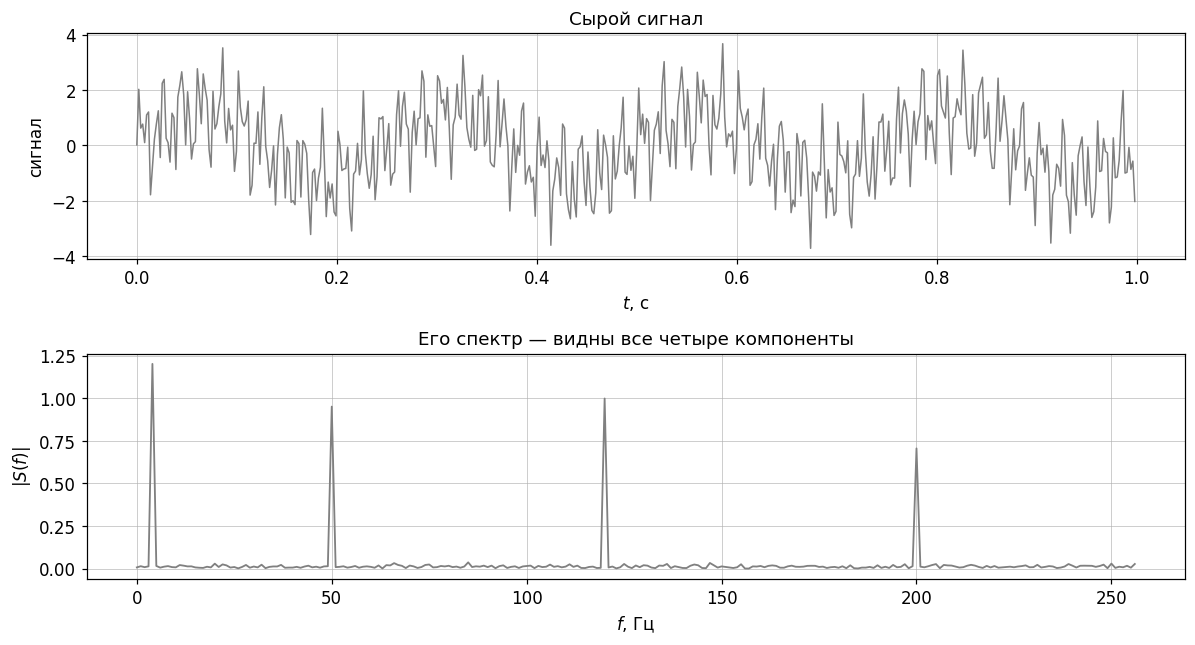

In [4]:
FS = 512.0     # частота дискретизации, Гц (Найквист 256 Гц)
N = 512        # длина окна, отсчётов

COMPONENTS = [
    (4.0, 1.2),     # дрейф изолинии — движение электрода
    (50.0, 0.95),   # сетевая наводка
    (120.0, 1.0),   # полезная составляющая
    (200.0, 0.7),   # высокочастотный шум
]

t, raw = make_signal(COMPONENTS, FS, N)
freqs_raw, spec_raw = spectrum(raw, FS)

print("Что положили в сигнал:")
for freq, amp in COMPONENTS:
    print("   %6g Гц, амплитуда %.2f" % (freq, amp))

fig, ax = plt.subplots(2, 1, figsize=(11, 6))
ax[0].plot(t, raw, color="gray", lw=1.0)
ax[0].set(xlabel="$t$, с", ylabel="сигнал", title="Сырой сигнал")
ax[1].plot(freqs_raw, spec_raw, color="gray", lw=1.2)
ax[1].set(xlabel="$f$, Гц", ylabel="$|S(f)|$", title="Его спектр — видны все четыре компоненты")
fig.tight_layout()
plt.show()

## Ячейка 4 · Полосовой фильтр плюс notch

Пропускаем полосу 20–160 Гц и дополнительно вырезаем 50 Гц.
Меняй `BAND` и `NOTCH_ON` — это те же ползунки, что в браузерной версии.

Полоса 20–160 Гц, notch 50 Гц: включён

 частота         до      после   что произошло
     4 Гц       1.20       0.03   убрана (2%)
    50 Гц       0.95       0.10   ослаблена (10%)
   120 Гц       1.00       0.99   прошла (99%)
   200 Гц       0.71       0.00   убрана (1%)


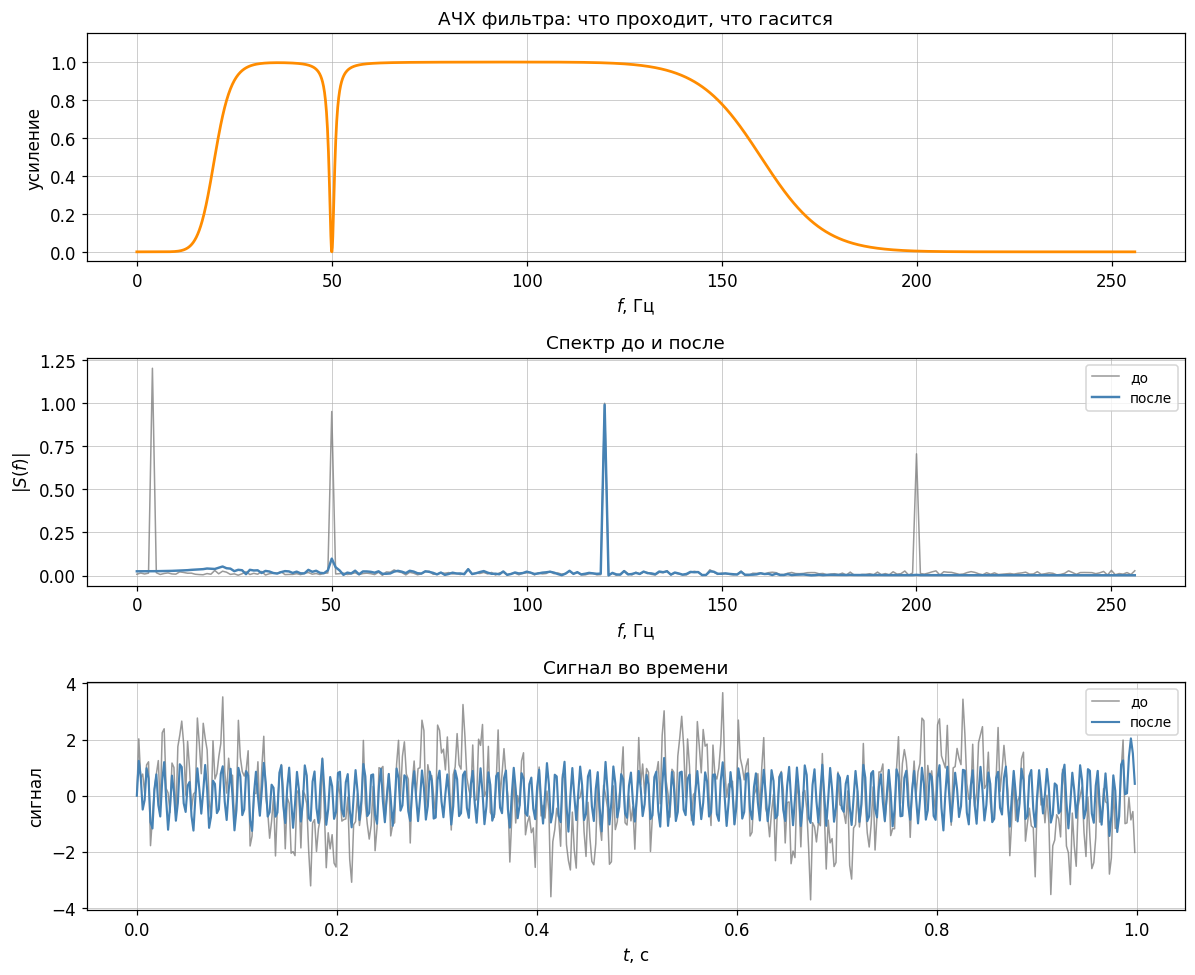

In [5]:
BAND = (20.0, 160.0)   # полоса пропускания (ФВЧ, ФНЧ), Гц
NOTCH_ON = True        # вырезать 50 Гц?

filtered = bandpass(raw, BAND, FS)
if NOTCH_ON:
    filtered = notch(filtered, 50.0, FS)

print("Полоса %g–%g Гц, notch 50 Гц: %s\n"
      % (BAND[0], BAND[1], "включён" if NOTCH_ON else "выключен"))
_, spec_flt = spectrum(filtered, FS)
report_components(COMPONENTS, freqs_raw, spec_raw, spec_flt, FS, N)

plot_before_after(t, raw, filtered, FS, BAND, 50.0 if NOTCH_ON else None)

Дрейф 4 Гц и шум 200 Гц срезаны полосовым, наводка 50 Гц — режекторным,
полезные 120 Гц прошли почти без потерь.

## Ячейка 5 · Чем круче фильтр, тем резче край

Порядок фильтра задаёт, насколько быстро усиление падает за границей полосы.
Низкий порядок — плавный, мягкий спад; высокий — почти отвесная стенка,
но фильтр становится «нервным» и сильнее звенит на переходах.

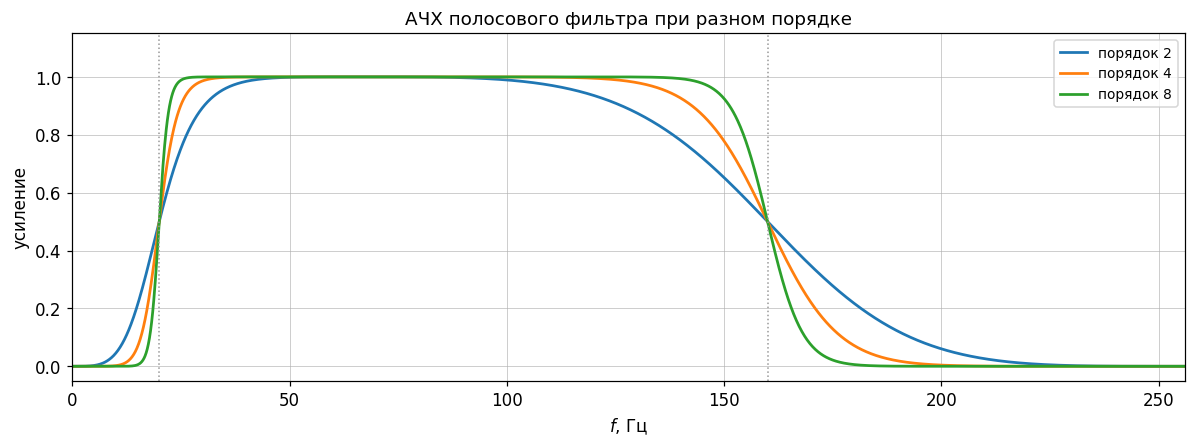

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.2))
for order in (2, 4, 8):
    f_resp, gain = response(BAND, FS, order=order)
    ax.plot(f_resp, gain, lw=1.8, label="порядок %d" % order)
for edge in BAND:
    ax.axvline(edge, color="0.6", ls=":", lw=1)
ax.set(xlabel="$f$, Гц", ylabel="усиление", xlim=(0, 256), ylim=(-0.05, 1.15),
       title="АЧХ полосового фильтра при разном порядке")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Ячейка 6 · Задержка: цена работы в реальном времени

`filtfilt` даёт нулевой сдвиг, потому что проходит сигнал дважды — вперёд и
назад. Второй проход требует знать будущее, поэтому в реальном времени так
нельзя. Односторонний фильтр (`sosfilt`) работает онлайн, но сдвигает сигнал.

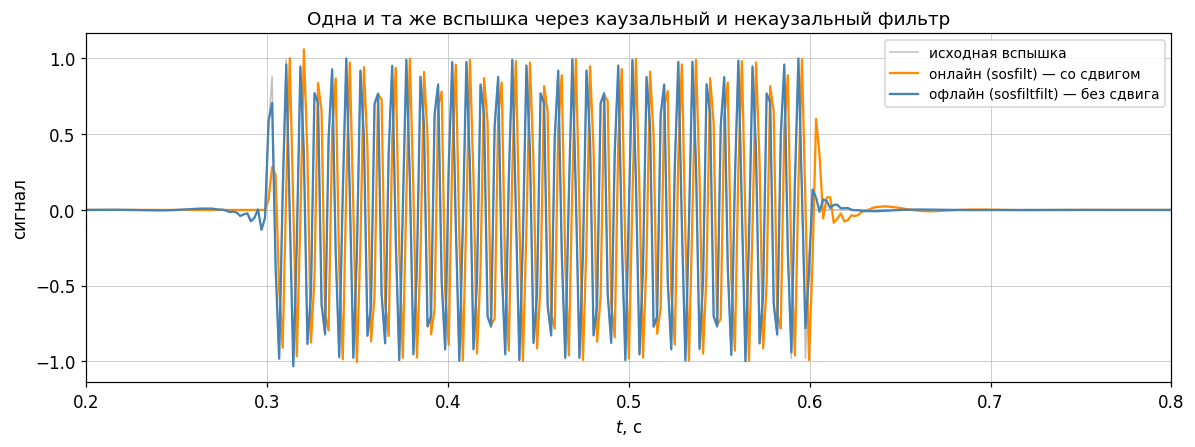

In [7]:
BURST_T = np.arange(int(1.0 * FS)) / FS
burst = np.sin(2 * np.pi * 120 * BURST_T) * (
    (BURST_T > 0.3) & (BURST_T < 0.6)).astype(float)

sos = signal.butter(4, BAND, btype="bandpass", fs=FS, output="sos")
online = signal.sosfilt(sos, burst)      # каузально: можно в реальном времени
offline = signal.sosfiltfilt(sos, burst)  # вперёд-назад: только офлайн

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(BURST_T, burst, color="0.75", lw=1.0, label="исходная вспышка")
ax.plot(BURST_T, online, color="darkorange", lw=1.5, label="онлайн (sosfilt) — со сдвигом")
ax.plot(BURST_T, offline, color="steelblue", lw=1.5, label="офлайн (sosfiltfilt) — без сдвига")
ax.set(xlabel="$t$, с", ylabel="сигнал", xlim=(0.2, 0.8),
       title="Одна и та же вспышка через каузальный и некаузальный фильтр")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Оранжевая кривая начинается позже исходной — это и есть задержка фильтра.
В управлении протезом она складывается с задержкой окна из лабы E4 и
напрямую определяет, насколько «тормозит» устройство.

## Задания

1. Задай свою полосу пропускания из таблицы вариантов и запиши, во сколько раз
   ослабла каждая компонента сигнала.
2. Выключи notch и сравни высоту пика на 50 Гц до и после. Объясни, почему
   полосовой фильтр 20–160 Гц сам по себе наводку не убирает.
3. Найди порядок фильтра, при котором компонента 200 Гц гасится минимум
   в 20 раз, а 120 Гц теряет не больше 10%.